# GPT-4o model with Azure OpenAI
<img src="https://github.com/retkowsky/images/blob/master/gpt4o.jpg?raw=true">

GPT-4o is the latest model from OpenAI. GPT-4o integrates text and images in a single model, enabling it to handle multiple data types simultaneously. This multimodal approach enhances accuracy and responsiveness in human-computer interactions. GPT-4o matches GPT-4 Turbo in English text and coding tasks while offering superior performance in non-English languages and vision tasks, setting new benchmarks for AI capabilities.

> Documentation: https://learn.microsoft.com/en-us/azure/ai-services/openai/concepts/models#gpt-4o-and-gpt-4-turbo

In [ ]:
! pip install openai requests gradio

In [37]:
import base64
import datetime
import glob
import gradio as gr
import openai
import os
import requests
import sys

from dotenv import load_dotenv
from io import BytesIO
from mimetypes import guess_type
from openai import AzureOpenAI
from PIL import Image

In [38]:
def check_openai_version():
    """
    Check Azure Open AI version
    """
    installed_version = openai.__version__

    try:
        version_number = float(installed_version[:3])
    except ValueError:
        print("Invalid OpenAI version format")
        return

    print(f"Installed OpenAI version: {installed_version}")

    if version_number < 1.0:
        print("[Warning] You should upgrade OpenAI to have version >= 1.0.0")
        print("To upgrade, run: %pip install openai --upgrade")
    else:
        print(f"[OK] OpenAI version {installed_version} is >= 1.0.0")

In [39]:
check_openai_version()

Installed OpenAI version: 1.58.1
[OK] OpenAI version 1.58.1 is >= 1.0.0


In [40]:
print(f"Today is {datetime.datetime.today().strftime('%d-%b-%Y %H:%M:%S')}")

Today is 12-Mar-2026 11:54:19


In [41]:
print(f"Python version: {sys.version}")

Python version: 3.13.1 (tags/v3.13.1:0671451, Dec  3 2024, 19:06:28) [MSC v.1942 64 bit (AMD64)]


In [42]:
print(f"OpenAI version: {openai.__version__}")

OpenAI version: 1.58.1


## 1 Settings

In [43]:
load_dotenv("azure.env")

# Azure OpenAI
api_type: str = "azure"
api_key = os.getenv("OPENAI_API_KEY")
api_base = os.getenv("OPENAI_API_BASE")

api_version = "2024-05-01-preview"

In [44]:
# This is the deployed name of your GPT-4o model from the Azure Open AI studio
model = "gpt-4o"

## 2 Testing the model

In [45]:
def gpt4o_text(prompt):
    """
    Gpt-4o model
    """
    client = AzureOpenAI(
        api_key=api_key,
        api_version=api_version,
        base_url=f"{api_base}/openai/deployments/{model}",
    )

    response = client.chat.completions.create(
        model=model,
        messages=[
            {"role": "system", "content": "You are a helpful assistant."},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                ],
            },
        ],
        max_tokens=2000,
        temperature=0.7,
    )

    return response

In [46]:
result = gpt4o_text("Who are you?")
print(result.choices[0].message.content)

I am an AI assistant created to help you with information, answer questions, and provide support on various topics. You can think of me as a knowledgeable and helpful virtual companion, here to make your life easier! How can I assist you today?


In [47]:
result = gpt4o_text("What is the capital of France?")
print(result.choices[0].message.content)

The capital of France is **Paris**.


In [48]:
result = gpt4o_text("What is an ARMA model?")
print(result.choices[0].message.content)

An **ARMA model** (AutoRegressive Moving Average model) is a statistical model used for analyzing and forecasting time series data. It combines two components:

1. **AutoRegressive (AR) component**: This part of the model expresses the current value of the time series as a linear combination of its past values. The AR part is characterized by the order \( p \), which indicates how many past values (lags) are used.
   \[
   X_t = \phi_1 X_{t-1} + \phi_2 X_{t-2} + \dots + \phi_p X_{t-p} + \epsilon_t
   \]
   Here:
   - \( X_t \) is the value of the time series at time \( t \),
   - \( \phi_1, \phi_2, \dots, \phi_p \) are the autoregressive coefficients,
   - \( \epsilon_t \) is the error term (white noise).

2. **Moving Average (MA) component**: This part models the relationship between the current value of the time series and past error terms. The MA part is characterized by the order \( q \), which indicates how many past error terms are used.
   \[
   X_t = \theta_1 \epsilon_{t-1} + \

## 3 Using an url image

In [49]:
def gpt4o_url(image_url, prompt):
    """
    Gpt-4o model using image url
    """
    client = AzureOpenAI(
        api_key=api_key,
        api_version=api_version,
        base_url=f"{api_base}/openai/deployments/{model}",
    )

    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": "You are a helpful assistant to analyse images.",
            },
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {"type": "image_url", "image_url": {"url": image_url}},
                ],
            },
        ],
        max_tokens=2000,
        temperature=0.0,
    )

    return response

In [53]:
import requests
from PIL import Image
from io import BytesIO

image_url = "https://raw.githubusercontent.com/retkowsky/images/master/jo.png"

response = requests.get(image_url)

print("Status:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))

if response.status_code == 200:
    img = Image.open(BytesIO(response.content))
    img.show()
else:
    print("Failed to load image")

Status: 200
Content-Type: image/png


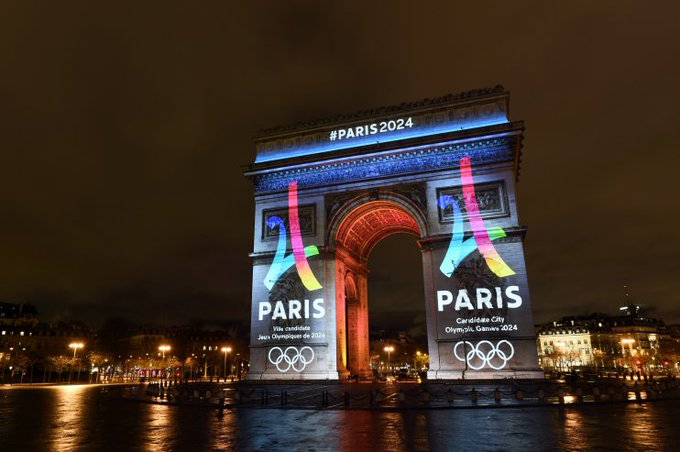

In [54]:
response = requests.get(image_url)
img = Image.open(BytesIO(response.content))
img

In [55]:
result = gpt4o_url(image_url, "Analyse this image")

print(result.choices[0].message.content)

This image shows the Arc de Triomphe in Paris illuminated at night with projections promoting the Paris 2024 Olympic Games. The projections include the Paris 2024 logo, the Olympic rings, and the text "#PARIS2024" at the top. The colorful logo and text emphasize Paris as the host city for the 2024 Summer Olympics. The surrounding area is lit with streetlights, and the wet pavement reflects the lights, adding to the dramatic effect of the scene.


## 4 Using an image file

In [56]:
def image_view(image_file):
    """
    View image using PIL
    """
    if not os.path.exists(image_file):
        print(f"[Error] Image file {image_file} does not exist.")
        return None

    else:
        print(image_file)
        img = Image.open(image_file)
        display(img)

In [57]:
def local_image_to_data_url(image_path):
    """
    Get the url of a local image
    """
    mime_type, _ = guess_type(image_path)

    if mime_type is None:
        mime_type = "application/octet-stream"

    with open(image_path, "rb") as image_file:
        base64_encoded_data = base64.b64encode(image_file.read()).decode("utf-8")

    return f"data:{mime_type};base64,{base64_encoded_data}"

In [58]:
def gpt4o_imagefile(image_file, prompt):
    """
    Gpt-4o model
    """
    client = AzureOpenAI(
        api_key=api_key,
        api_version=api_version,
        base_url=f"{api_base}/openai/deployments/{model}",
    )

    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "system",
                "content": "You are a helpful assistant to analyse images.",
            },
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": prompt},
                    {
                        "type": "image_url",
                        "image_url": {"url": local_image_to_data_url(image_file)},
                    },
                ],
            },
        ],
        max_tokens=2000,
        temperature=0.0,
    )

    return response

### Example 1

image1.jpg


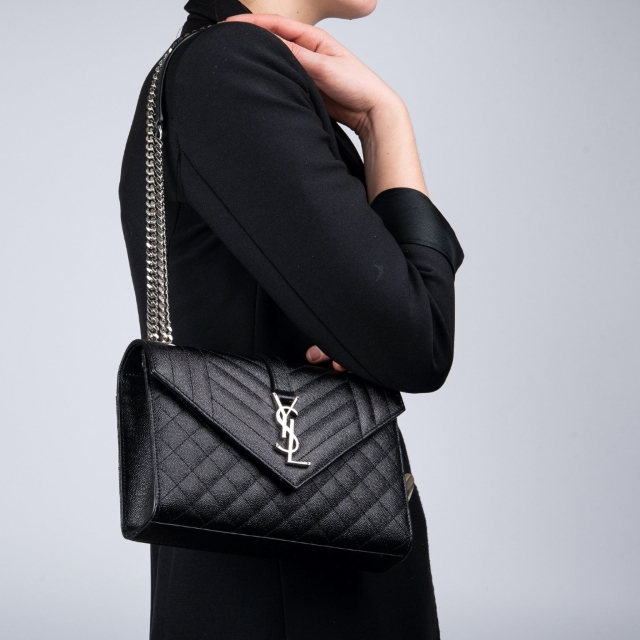

In [59]:
image_file = "image1.jpg"

image_view(image_file)

In [60]:
result = gpt4o_imagefile(
    image_file, "Extract the main article, its brand and its color."
)
print(result.choices[0].message.content)

- **Main Article**: Handbag  
- **Brand**: Yves Saint Laurent (YSL)  
- **Color**: Black


In [61]:
context = """ 
You are a fashion expert, familiar with identifying features of fashion articles from images.
A user uploads an image and asks you to describe one particular piece in the shot: jacket, shoes, pants, \
watches, etc.
"""

prompt = """
You respond with your analysis of the following fields:

1. ITEM'S TYPE: Identify if it's a top, bottom, dress, outerwear, footwear, bag, jewelry...
2. BRAND: identity the brand of the item.
3. COLOR: Note the main color(s) and any secondary colors.
4. PATTERN: Identify any visible patterns such as stripes, florals, animal print, or geometric designs.\
Feel free to use any other patterns here.
5. MATERIAL: Best guess at the material that the item is made from.
6. FEATURES: Note any unique details or embellishments, like embroidery, sequins, studs, fringes, buttons,
zippers...
7. ITEM TYPE SPECIFIC: For each type of item, feel free to add any additional descriptions that are relevant \
to help describe the item. For example, for a jacket you can include the neck and sleeve design, plus the length.
8. MISC.: Anything else important that you notice.
9. SIZE: Print the size of the item if you get it from the image.
10. ITEM SUMMARY: Write a one line summary for this item.
11. ITEM CLASSIFICATION: Classify this item into CLOTHES, BAG, SHOES, WATCH or OTHERS.
12. ITEM TAGS: Generate 10 tags to describe this item. Each tags should be separated with a comma.
13. STORIES: Write multiple stories about this product in 5 lines.
14. TWEETER PUBLICATION: Write a tweeter ad for this item with some hashtags and emojis.
15. ECOMMERCE AD: Generate an item description for a publication on a ecommerce website with a selling message.
16. FRENCH ECOMMERCE AD: Generate an item description in French for a publication on a ecommerce website with \
a selling message.

The output should be a numbered bulleted list. Just print an empty line between each items starting at item 12.
"""

retailprompt = context + prompt

In [62]:
result = gpt4o_imagefile(image_file, retailprompt)
print(result.choices[0].message.content)

1. **ITEM'S TYPE**: Bag (Shoulder Bag)

2. **BRAND**: Yves Saint Laurent (YSL)

3. **COLOR**: Black with silver hardware.

4. **PATTERN**: Quilted chevron pattern.

5. **MATERIAL**: Likely leather with a metallic chain strap.

6. **FEATURES**:  
   - YSL logo in silver on the front flap.  
   - Quilted chevron stitching.  
   - Silver chain strap with leather shoulder pad.  
   - Envelope-style flap closure.

7. **ITEM TYPE SPECIFIC**:  
   - Medium-sized shoulder bag.  
   - Structured design with a sleek and elegant silhouette.  
   - Versatile for both casual and formal occasions.

8. **MISC.**: The bag exudes luxury and sophistication, making it a timeless accessory.

9. **SIZE**: Not specified in the image.

10. **ITEM SUMMARY**: A luxurious black YSL shoulder bag with a quilted chevron pattern and silver hardware, perfect for elevating any outfit.

11. **ITEM CLASSIFICATION**: BAG

12. **ITEM TAGS**: YSL bag, black shoulder bag, luxury handbag, quilted bag, chevron pattern, silve

### Example 2

image2.jpg


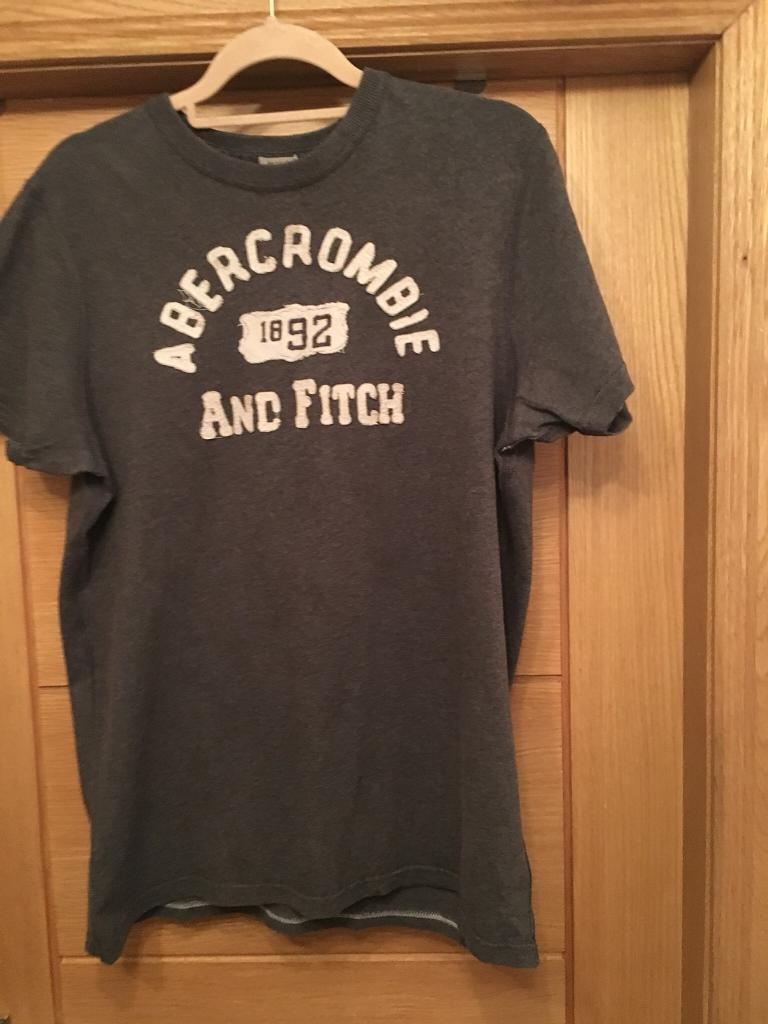

In [63]:
image_file = "image2.jpg"

image_view(image_file)

In [64]:
result = gpt4o_imagefile(image_file, retailprompt)
print(result.choices[0].message.content)

1. **ITEM'S TYPE**: Top (T-shirt)

2. **BRAND**: Abercrombie & Fitch

3. **COLOR**: Dark gray with white text.

4. **PATTERN**: Solid base with printed text and logo.

5. **MATERIAL**: Likely cotton or a cotton blend.

6. **FEATURES**: Crew neck, short sleeves, printed brand name and "1892" logo on the front.

7. **ITEM TYPE SPECIFIC**: Classic crew-neck T-shirt with a relaxed fit and standard length.

8. **MISC.**: The text and logo design give it a casual and sporty vibe.

9. **SIZE**: Not visible in the image.

10. **ITEM SUMMARY**: A dark gray Abercrombie & Fitch T-shirt with a printed logo and text, perfect for casual wear.

11. **ITEM CLASSIFICATION**: CLOTHES

12. **ITEM TAGS**: T-shirt, Abercrombie & Fitch, casual wear, crew neck, short sleeves, dark gray, printed logo, cotton blend, sporty style, relaxed fit.

---

13. **STORIES**:  
   - This Abercrombie & Fitch T-shirt is a timeless addition to your casual wardrobe.  
   - The dark gray color and bold white logo make it vers

### Example 3

image3.png


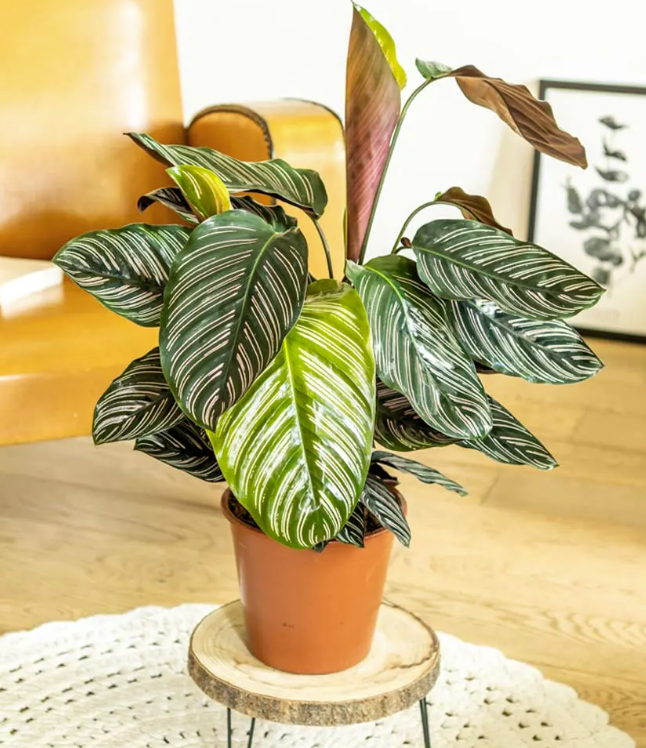

In [65]:
image_file = "image3.png"

image_view(image_file)

In [66]:
context = """
You are a plant and flowers expert, familiar with identifying plants and flowers from images.
A user uploads an image and asks you to describe one particular piece in the shot: flowers, plants...
"""

prompt = """
You respond with your analysis of the following fields:

1. ITEM'S TYPE: Identify the plant species.
2. COLOR: Note the main color(s) and any secondary colors of the plant.
3. COUNTRIES: Identify the country where this plant came from.
4. WATER: Identify the water preferences of this plant.
5. SUN: Identify the light preference of this plant.
6. TEMPERATURE: Identify the best temperature for this plant.
7. FERTILIZATION: What about fertilization?
8. DISEASE: What are the main diseases for this plant?
9. SOIL: What is the best soil?
10. SOIL PH: What is the best soil PH?
11. FLOWERING: What is the flowering period?
12. TOXICITY: What is the toxicity?
13. ITEM TYPE SPECIFIC: For each type of item, feel free to add any additional descriptions that are relevant \
to help describe the item.
14. MISC.: Anything else important that you notice about the plant.
15. SIZE: What is the usual size of this plant?
16. ITEM SUMMARY: Write a one-line summary for this item.
17. ITEM CLASSIFICATION: Classify this item into "plant for beginners", "plant that needs attention", \
"plant for experts".
18. ITEM TAGS: Generate 10 tags to describe this plant. Each tag should be separated with a comma.
19. STORIES: Write multiple stories about this plant in 5 lines.
20. TWEETER PUBLICATION: Write a tweeter ad for this plant with some hashtags and emojis.
21. ECOMMERCE AD: Generate a plant description for a publication on an ecommerce website with a selling message.
22. FRENCH ECOMMERCE AD: Generate a plant description in French for a publication on an ecommerce website with \
a selling message.

The output should be a numbered bulleted list.
"""

flower_prompt = context + prompt

In [67]:
result = gpt4o_imagefile(image_file, flower_prompt)
print(result.choices[0].message.content)

1. **ITEM'S TYPE**: Calathea ornata (commonly known as the Pinstripe Plant).
2. **COLOR**: Dark green leaves with pinkish-white pinstripes; undersides of leaves are purple.
3. **COUNTRIES**: Native to South America, particularly Brazil and Colombia.
4. **WATER**: Prefers consistently moist soil but not waterlogged; avoid letting the soil dry out completely.
5. **SUN**: Thrives in bright, indirect light; avoid direct sunlight as it can scorch the leaves.
6. **TEMPERATURE**: Best temperature range is 18–24°C (65–75°F); avoid cold drafts.
7. **FERTILIZATION**: Feed with a balanced liquid fertilizer every 4–6 weeks during the growing season (spring and summer).
8. **DISEASE**: Susceptible to root rot if overwatered, as well as pests like spider mites, mealybugs, and aphids.
9. **SOIL**: Prefers well-draining, rich, and slightly acidic soil.
10. **SOIL PH**: Ideal soil pH is between 6.0 and 6.5.
11. **FLOWERING**: Rarely flowers indoors; in its natural habitat, it produces small, inconspicu

In [68]:
result = gpt4o_imagefile(image_file, flower_prompt + " Print all the results in French")
print(result.choices[0].message.content)

1. **TYPE D'ARTICLE** : Calathea ornata (aussi appelée "Plante zébrée" ou "Plante pin-stripe").  
2. **COULEUR** : Feuilles vert foncé avec des rayures blanches et des nuances de rose sur le dessous.  
3. **PAYS** : Originaire des forêts tropicales d'Amérique du Sud, notamment du Brésil et de la Colombie.  
4. **EAU** : Préfère un sol constamment humide mais pas détrempé. Arrosage régulier avec de l'eau non calcaire.  
5. **SOLEIL** : Lumière indirecte vive, évitez la lumière directe du soleil qui peut brûler les feuilles.  
6. **TEMPÉRATURE** : Température idéale entre 18 et 24 °C. Évitez les courants d'air froid.  
7. **FERTILISATION** : Fertilisez une fois par mois au printemps et en été avec un engrais liquide pour plantes d'intérieur.  
8. **MALADIES** : Sensible aux acariens, cochenilles et taches foliaires dues à un excès d'humidité.  
9. **SOL** : Sol bien drainé, riche en matière organique. Un mélange pour plantes tropicales est idéal.  
10. **PH DU SOL** : Légèrement acide à 

### Example 4

image4.jpg


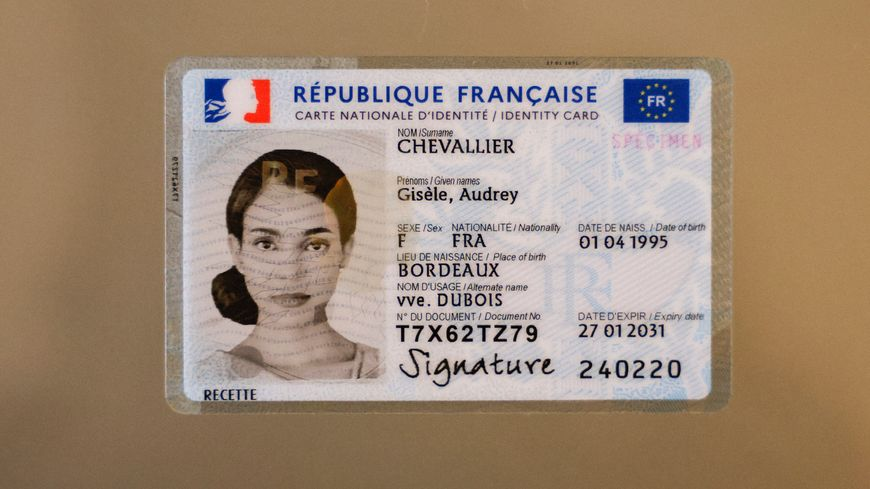

In [69]:
image_file = "image4.jpg"

image_view(image_file)

In [70]:
result = gpt4o_imagefile(
    image_file, "Get the name, dob and the expiration date into a json file format"
)

print(result.choices[0].message.content)

```json
{
  "name": "Chevallier Gisèle Audrey",
  "date_of_birth": "01/04/1995",
  "expiration_date": "27/01/2031"
}
```


In [72]:
from datetime import datetime

now = datetime.now()
current_month = now.strftime("%B")
current_year = now.strftime("%Y")

print(current_month, current_year)

March 2026


In [73]:
now = datetime.now()
current_month = now.strftime("%B")
current_year = now.strftime("%Y")

result = gpt4o_imagefile(
    image_file, f"We are in {current_month} {current_year}. What is the age of Gisèle?"
)

print(result.choices[0].message.content)

Gisèle Audrey Chevallier was born on April 1, 1995. In March 2026, she would be **30 years old**, turning 31 on April 1, 2026.


In [74]:
result = gpt4o_imagefile(image_file, "What is the country?")

print(result.choices[0].message.content)

The country is France.


In [75]:
result = gpt4o_imagefile(
    image_file, "Classify this into PASSPORT, DRIVER LICENCE, ID, TRANSPORTATION CARD"
)

print(result.choices[0].message.content)

This is classified as an **ID (Identity Card)**.


### Example 5

image5.jpg


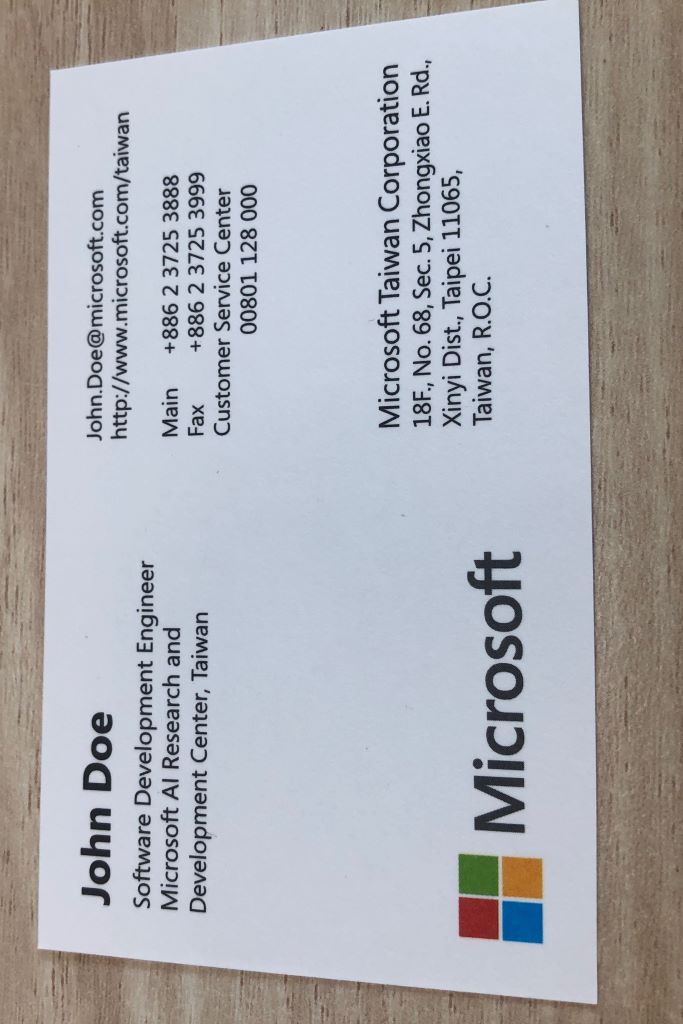

In [76]:
image_file = "image5.jpg"

image_view(image_file)

In [77]:
result = gpt4o_imagefile(image_file, "What is the name and the email?")

print(result.choices[0].message.content)

The name on the card is **John Doe**, and the email address is **John.Doe@microsoft.com**.


### Example 6

image6.png


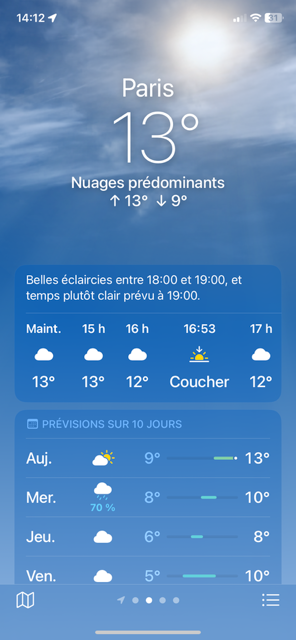

In [78]:
image_file = "image6.png"

image_view(image_file)

In [79]:
result = gpt4o_imagefile(
    image_file, "What is the time and the percentage of available memory?"
)

print(result.choices[0].message.content)

The time displayed in the image is **14:12** (2:12 PM). 

The percentage of available memory is not shown in this image.


In [80]:
result = gpt4o_imagefile(
    image_file, "Any rain during the week?")
print(result.choices[0].message.content)

Yes, according to the forecast, there is a 70% chance of rain on Wednesday. The other days appear to be cloudy or clear without significant rain chances.


### Example 7

image7.jpg


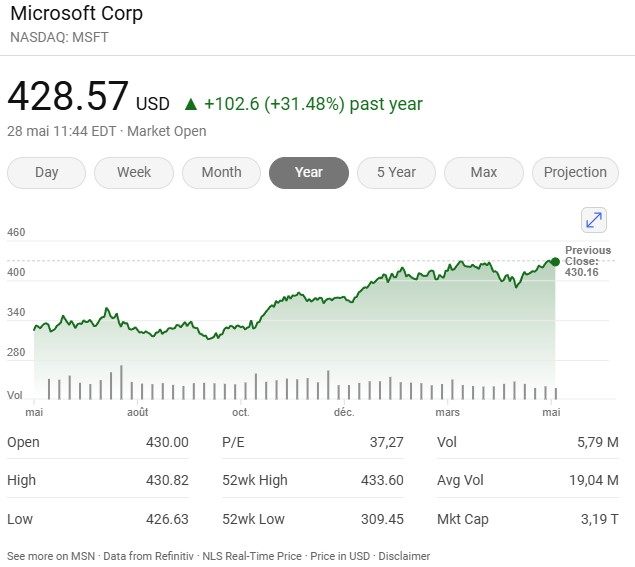

In [81]:
image_file = "image7.jpg"

image_view(image_file)

In [82]:
result = gpt4o_imagefile(image_file, "Describe this")

print(result.choices[0].message.content)

This is a stock performance chart for Microsoft Corporation (NASDAQ: MSFT) over the past year. Here are the key details:

- **Current Price**: $428.57 USD
- **Change Over the Past Year**: +$102.6 (+31.48%)
- **Date and Time**: May 28, 11:44 EDT (Market Open)
- **Timeframe**: Yearly view is selected.
- **Opening Price**: $430.00
- **High Price**: $430.82
- **Low Price**: $426.63
- **52-Week High**: $433.60
- **52-Week Low**: $309.45
- **P/E Ratio**: 37.27
- **Volume (Vol)**: 5.79 million
- **Average Volume (Avg Vol)**: 19.04 million
- **Market Capitalization (Mkt Cap)**: $3.19 trillion

The chart shows a steady upward trend in Microsoft's stock price over the past year, with some fluctuations. The stock is currently near its 52-week high.


In [83]:
result = gpt4o_imagefile(
    image_file, "You are a financial analyst. What is your report on this stock?"
)

print(result.choices[0].message.content)

### Financial Analysis Report: Microsoft Corp (NASDAQ: MSFT)

#### **Current Stock Performance**
- **Price**: $428.57 USD
- **Change (1 Year)**: +$102.6 (+31.48%)
- **52-Week Range**: $309.45 - $433.60
- **Market Cap**: $3.19 Trillion USD
- **P/E Ratio**: 37.27 (Price-to-Earnings Ratio)
- **Volume**: 5.79M (Current), 19.04M (Average)

#### **Key Observations**
1. **Strong Growth**: The stock has shown significant growth over the past year, with a 31.48% increase in value. This indicates strong investor confidence and positive market sentiment.
   
2. **Near 52-Week High**: The stock is trading close to its 52-week high of $433.60, suggesting strong momentum and potential for further upside.

3. **High Market Cap**: Microsoft remains one of the largest companies globally, with a market capitalization of $3.19 trillion, reflecting its dominant position in the technology sector.

4. **P/E Ratio**: The P/E ratio of 37.27 is relatively high, indicating that the stock may be priced at a prem

### Example 8

image8.png


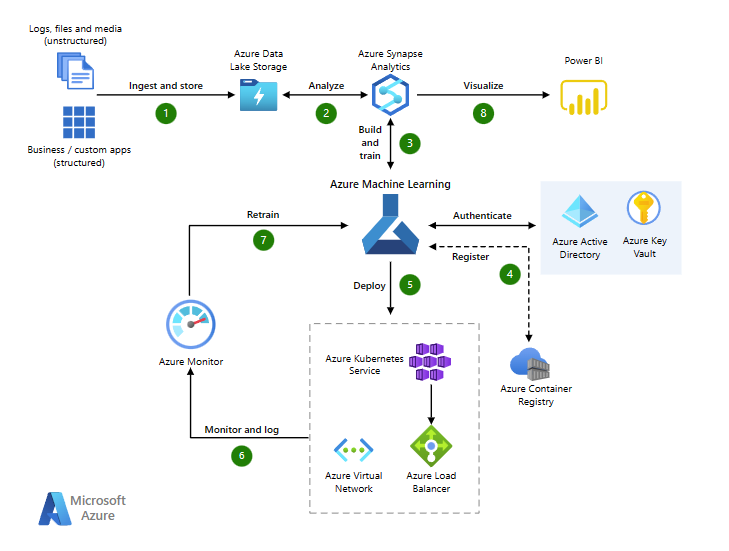

In [84]:
image_file = "image8.png"

image_view(image_file)

In [85]:
result = gpt4o_imagefile(image_file, "Describe this architecture")

print(result.choices[0].message.content)

This diagram represents an architecture for a machine learning workflow using Microsoft Azure services. It outlines the process of ingesting, analyzing, training, deploying, monitoring, and visualizing data and machine learning models. Here's a step-by-step description:

### 1. **Data Ingestion and Storage**
   - **Sources**: Logs, files, media (unstructured data), and business/custom applications (structured data).
   - **Service**: Data is ingested and stored in **Azure Data Lake Storage**, which provides scalable and secure storage for large datasets.

### 2. **Data Analysis**
   - **Service**: Data is analyzed using **Azure Synapse Analytics**, which enables big data processing and analytics.

### 3. **Model Building and Training**
   - **Service**: Machine learning models are built and trained using **Azure Machine Learning**. This step involves preparing the data, training the model, and evaluating its performance.

### 4. **Authentication and Registration**
   - **Services**: 
 

In [86]:
result = gpt4o_imagefile(
    image_file,
    "List the Azure technologies I need to provision into my Azure subscription.",
)

print(result.choices[0].message.content)

Based on the diagram, the following Azure technologies need to be provisioned in your Azure subscription:

1. **Azure Data Lake Storage**: For ingesting and storing structured and unstructured data.
2. **Azure Synapse Analytics**: For analyzing data and building machine learning models.
3. **Azure Machine Learning**: For training, deploying, and managing machine learning models.
4. **Azure Active Directory**: For authentication and identity management.
5. **Azure Key Vault**: For securely storing secrets, keys, and certificates.
6. **Azure Kubernetes Service (AKS)**: For deploying and managing containerized applications.
7. **Azure Container Registry**: For storing and managing container images.
8. **Azure Virtual Network**: For networking and connectivity between resources.
9. **Azure Load Balancer**: For distributing traffic across resources.
10. **Azure Monitor**: For monitoring and logging application and resource performance.
11. **Power BI**: For visualizing data and insights.

T

### Image 9

image9.jpg


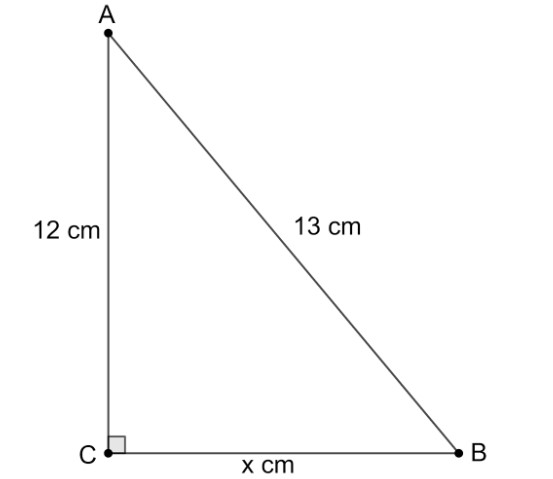

In [87]:
image_file = "image9.jpg"

image_view(image_file)

In [88]:
result = gpt4o_imagefile(image_file, "What is the dimension of the CB line?")

print(result.choices[0].message.content)

This is a right triangle, and we can use the Pythagorean theorem to find the length of the line \( CB \) (denoted as \( x \)).

The Pythagorean theorem states:
\[
a^2 + b^2 = c^2
\]
where \( a \) and \( b \) are the lengths of the two legs, and \( c \) is the hypotenuse.

Here:
- \( AC = 12 \, \text{cm} \) (one leg),
- \( CB = x \, \text{cm} \) (the other leg),
- \( AB = 13 \, \text{cm} \) (the hypotenuse).

Substitute the values into the formula:
\[
12^2 + x^2 = 13^2
\]
\[
144 + x^2 = 169
\]
\[
x^2 = 169 - 144
\]
\[
x^2 = 25
\]
\[
x = \sqrt{25}
\]
\[
x = 5 \, \text{cm}
\]

Thus, the dimension of \( CB \) is **5 cm**.


In [89]:
result = gpt4o_imagefile(image_file, "What is the angle between AC and CB")
print(result.choices[0].message.content)

The triangle shown is a right triangle with a right angle at \( C \). The angle between \( AC \) and \( CB \) is therefore **90°**, as indicated by the square marking at \( C \).


### Image 10

image10.png


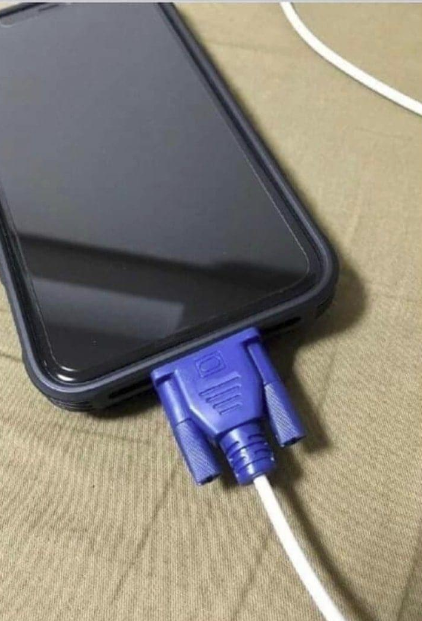

In [90]:
image_file = "image10.png"

image_view(image_file)

In [91]:
result = gpt4o_imagefile(image_file, "What's wrong here?")

print(result.choices[0].message.content)

This image shows a phone with a VGA connector plugged into its charging port, which is not compatible. VGA connectors are typically used for video output to monitors or projectors, not for charging or data transfer with phones. This setup is humorous and impractical, as the VGA connector cannot serve any functional purpose with the phone.


### Image 11

image11.jpg


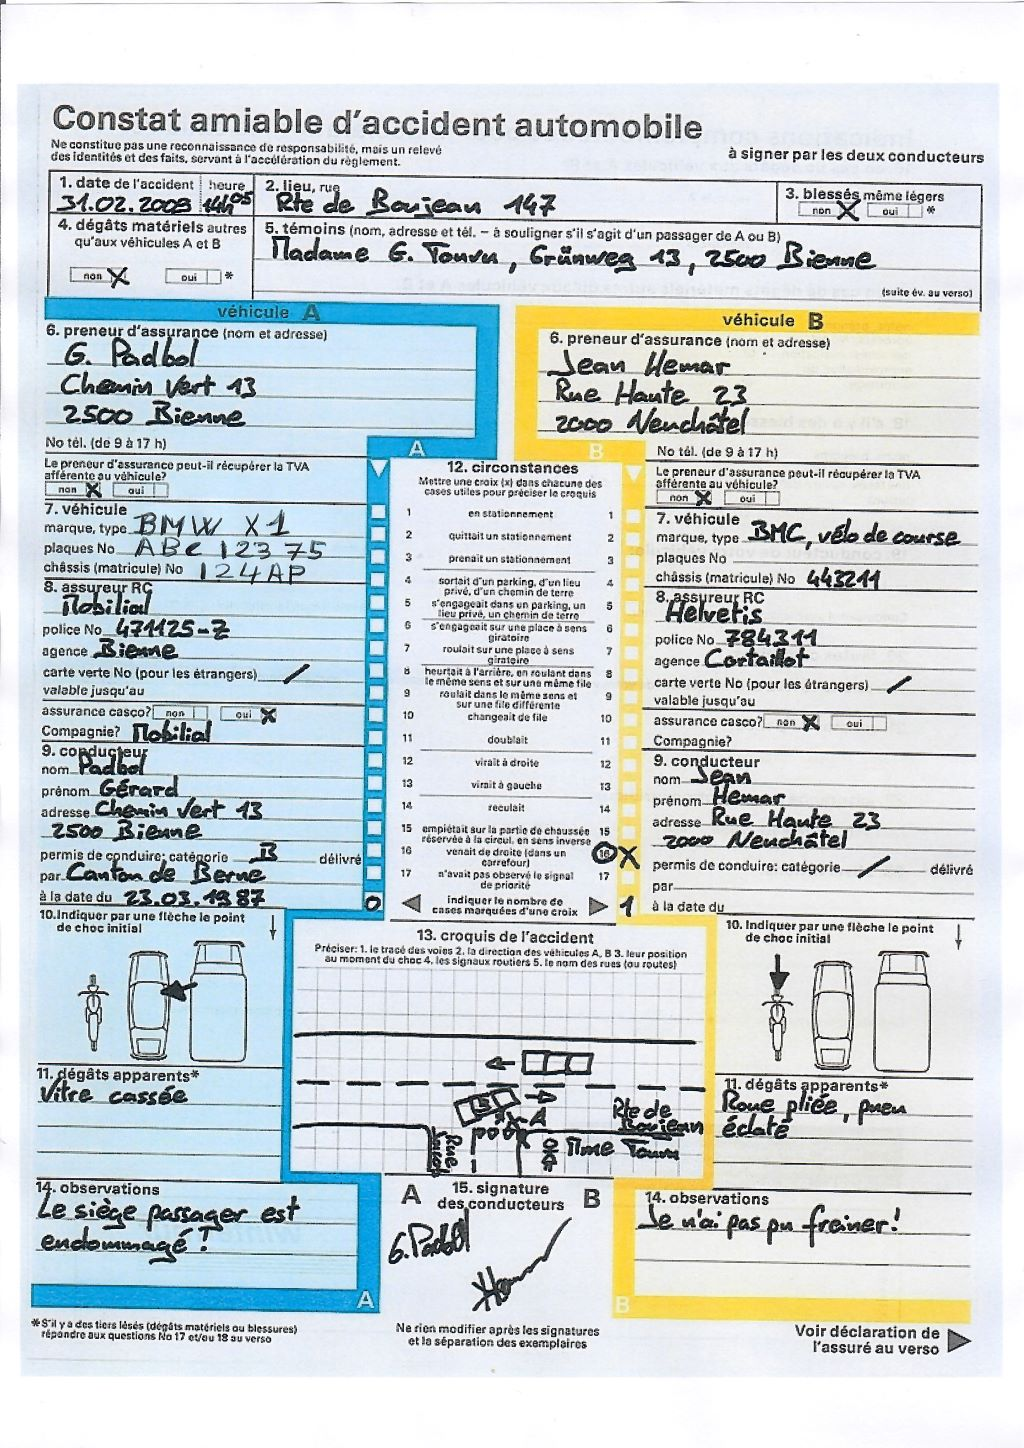

In [92]:
image_file = "image11.jpg"

image_view(image_file)

In [93]:
prompt = "Classify this document into 'Driver licence', 'Passport', 'European Accident form', 'Others'"

result = gpt4o_imagefile(image_file, prompt)
print(result.choices[0].message.content)

This document is classified as a **European Accident Form**. It is used to record details of a car accident and is typically filled out by both parties involved.


In [94]:
prompt = "What is the language used in this document?"

result = gpt4o_imagefile(image_file, prompt)
print(result.choices[0].message.content)

The language used in this document is **French**.


In [95]:
prompt = "Generate a summary."

result = gpt4o_imagefile(image_file, prompt)
print(result.choices[0].message.content)

This document is a "Constat amiable d'accident automobile," a European accident report form used to record details of a car accident. It includes information about the date, location, involved parties, vehicles, insurance details, and circumstances of the accident.

### Key Details:
1. **Date and Location**: The accident occurred on 31.02.2023 at Rue de Boujean 467.
2. **Vehicles Involved**:
   - **Vehicle A**: BMW X1, license plate ABC 123 75, insured by Tobilial.
   - **Vehicle B**: BMC bicycle, insured by Helvetis.
3. **Drivers**:
   - **Driver A**: Gérard Padbol, residing at Chemin Vert 13, 2500 Bienne.
   - **Driver B**: Jean Hemar, residing at Rue Haute 23, 2000 Neuchâtel.
4. **Damage**:
   - Vehicle A: Broken window and damaged passenger seat.
   - Vehicle B: Bent wheel and damaged tire.
5. **Circumstances**: The form indicates the accident occurred due to a failure to brake (noted by Driver B).
6. **Sketch**: A diagram illustrates the collision between the car and the bicycle.


In [96]:
prompt = "What are the names, cars models of vehicles A and B? Print the results in a json file format."

result = gpt4o_imagefile(image_file, prompt)
print(result.choices[0].message.content)

```json
{
  "vehicle_A": {
    "name": "G. Padbol",
    "car_model": "BMW X1"
  },
  "vehicle_B": {
    "name": "Jean Hemar",
    "car_model": "BMC, vélo de course"
  }
}
```


In [97]:
prompt = "What are the damages for vehicles A and B?"

result = gpt4o_imagefile(image_file, prompt)
print(result.choices[0].message.content)

Based on the document:

### Vehicle A (BMW X1):
- **Damages**: 
  - Broken window ("Vitre cassée").
  - Passenger seat is damaged ("Le siège passager est endommagé").

### Vehicle B (BMC bicycle):
- **Damages**: 
  - Bent wheel and damaged tire ("Roue pliée, pneu éclaté").


In [98]:
prompt = "Do we have injured people?"

result = gpt4o_imagefile(image_file, prompt)
print(result.choices[0].message.content)

No, the box for "injured people" (even minor injuries) is marked "non" (no) in section 3 of the document.


In [99]:
prompt = "Do we have some witness?"

result = gpt4o_imagefile(image_file, prompt)
print(result.choices[0].message.content)

Yes, the document indicates there is a witness. In section 5 ("témoins"), the name and address of the witness are provided: **Thadane E. Yannu, Granges 43, 2500 Bienne**.


In [100]:
prompt = "Explain the drawings from section number 10 for vehicles A and B"

result = gpt4o_imagefile(image_file, prompt)
print(result.choices[0].message.content)

The drawings in section 10 of the document illustrate the positions and movements of vehicles A and B at the time of the accident. Here's the explanation:

### Vehicle A:
- **Representation**: Vehicle A is depicted as a car.
- **Position**: It is shown traveling straight on the road.
- **Impact Point**: The drawing indicates that the collision occurred on the right side of Vehicle A.
- **Movement**: The arrow suggests that Vehicle A was moving forward at the time of the accident.

### Vehicle B:
- **Representation**: Vehicle B is depicted as a bicycle.
- **Position**: It is shown crossing the road from the right side, perpendicular to Vehicle A's path.
- **Impact Point**: The drawing indicates that the collision occurred at the front of Vehicle B.
- **Movement**: The arrow suggests that Vehicle B was moving across the road when the accident happened.

### Interaction:
The drawings show that Vehicle B (the bicycle) crossed the path of Vehicle A (the car), leading to the collision. The p

In [101]:
prompt = "Explain the drawing from section number 13"

result = gpt4o_imagefile(image_file, prompt)
print(result.choices[0].message.content)

Section 13 of the document is labeled "Croquis de l'accident" (Sketch of the accident). It provides a visual representation of the accident scenario, including the positions and movements of the vehicles involved.

### Explanation of the drawing:
1. **Road Layout**:
   - The sketch shows a road with lanes and markings.
   - The road is labeled "Rue de Boujean."

2. **Vehicles**:
   - Vehicle A (BMW X1) is represented as a rectangular box on the right side of the road.
   - Vehicle B (BMC bicycle) is represented as a smaller box on the left side of the road.

3. **Collision Point**:
   - The collision point is marked with an "X" where the two vehicles intersect.

4. **Arrows**:
   - Arrows indicate the direction of movement for both vehicles before the collision.

5. **Additional Notes**:
   - The sketch includes labels and annotations, such as "100%" and "3 Time Tour," which may refer to the circumstances or observations related to the accident.

This section is used to visually clarif

In [ ]:
prompt = "Do we have signatures on section 15? Just say YES or NO.\
IF the answer is YES, how many signatures do we have? Just print the number"

result = gpt4o_imagefile(image_file, prompt)
print(result.choices[0].message.content)

YES
2


## 5 WebApp

In [102]:
client = AzureOpenAI(
    api_key=api_key,
    api_version=api_version,
    base_url=f"{api_base}/openai/deployments/{model}",
)

In [103]:
def gpt4o_webapp_fn(pil_image, prompt):
    """
    GPT-4 model integration for analyzing images.
    """
    # Save image to an in-memory buffer
    buffer = BytesIO()
    pil_image.save(buffer, format="JPEG")
    buffer.seek(0)

    # Encode the image to base64
    image_data = base64.b64encode(buffer.read()).decode('utf-8')
    image_url = f"data:image/jpeg;base64,{image_data}"

    # Construct the messages
    messages = [
        {"role": "system", "content": "You are a helpful assistant to analyse images."},
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": image_url}},
            ],
        },
    ]

    # Call the Azure OpenAI API
    response = client.chat.completions.create(
        model=model,
        messages=messages,
        max_tokens=2000,
        temperature=0.0,
    )

    return response.choices[0].message.content

In [104]:
image_url = "https://github.com/retkowsky/images/blob/master/gpt4o.jpg?raw=true"
logo = "<center> <img src= {} width=200px></center>".format(image_url)
title = "GPT-4o model with Azure OpenAI"

inputs = [
    gr.Image(type="pil", label="Your image"),
    gr.Text(label="Your prompt"),
]
outputs = [
    gr.Text(label="GPT-4o results"),
]
theme = "gradio/soft"  # https://huggingface.co/spaces/gradio/theme-gallery

gp4o_webapp = gr.Interface(
    fn=gpt4o_webapp_fn,
    inputs=inputs,
    outputs=outputs,
    description=logo,
    title=title,
    theme=theme,
)

gp4o_webapp.launch(share=True)

c:\Users\MandugunduVenkateswa\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:140: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\MandugunduVenkateswa\.cache\huggingface\hub\spaces--gradio--soft. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


> End